In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Set a random seed so our results are reproducible
np.random.seed(42)

# 2. Simulate 1,000 different food safety batch measurements
n_samples = 1000

# Randomly generate environmental conditions within realistic limits
temperature = np.random.uniform(4, 45, n_samples)       # 4°C (fridge) to 45°C (warm room)
ph = np.random.uniform(4.0, 8.5, n_samples)             # Acidic to slightly alkaline
water_activity = np.random.uniform(0.85, 1.0, n_samples) # Dry to completely moist

# 3. Define the actual biological ground truth (simplified Cardinal Parameter model)
# Growth peaks around 37°C, pH 7, and high water activity.
def calculate_true_growth(temp, p_h, aw):
    # If it's too cold or too dry, bacteria cannot grow (growth rate = 0)
    if temp < 5 or aw < 0.90 or p_h < 4.5:
        return 0.0

    # Biological growth curve simulation
    temp_factor = np.maximum(0, 1 - ((temp - 37) / (37 - 5))**2)
    ph_factor = np.maximum(0, 1 - ((p_h - 7.0) / (7.0 - 4.5))**2)
    aw_factor = np.maximum(0, (aw - 0.90) / (1.0 - 0.90))

    # Maximum potential growth rate of our theoretical pathogen (log10 CFU/hour)
    max_rate = 1.2

    return max_rate * temp_factor * ph_factor * aw_factor

# Apply our biological rule to generate the growth rates for our dataset
true_growth_rates = [calculate_true_growth(t, p, a) for t, p, a in zip(temperature, ph, water_activity)]

# Add a tiny bit of random real-world "measurement noise" to make it realistic for the AI
noise = np.random.normal(0, 0.05, n_samples)
observed_growth_rates = np.maximum(0, np.array(true_growth_rates) + noise)

# 4. Create our clean Pandas DataFrame
df = pd.DataFrame({
    'Temperature_C': temperature,
    'pH': ph,
    'Water_Activity': water_activity,
    'Growth_Rate': observed_growth_rates
})

# Display the first 5 rows of our data
print("Successfully generated biological training dataset!")
df.head()

Successfully generated biological training dataset!


,Temperature_C,pH,Water_Activity,Growth_Rate
0,19.356145,4.833098,0.889256,0.052997
1,42.979287,6.438554,0.887047,0.030850
2,34.011752,7.928256,0.985938,0.915509
3,28.544998,7.295012,0.887432,0.000000
4,10.396764,7.629525,0.890792,0.060597


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Separate our inputs (X) from our target output (y)
X = df[['Temperature_C', 'pH', 'Water_Activity']]
y = df['Growth_Rate']

# 2. Split into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize our AI Model
# n_estimators=100 means we are using a forest of 100 decision trees
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 4. Train the model! (This is where the AI learns the biological patterns)
model.fit(X_train, y_train)

# 5. Evaluate how well the model learned by testing it on the unseen test data
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Training Complete ---")
print(mean_squared_error)
print(f"Mean Squared Error (Lower is better): {mse:.4f}")
print(f"R-squared Score (Closer to 1.0 is better): {r2:.4f}")

--- Model Training Complete ---
<function mean_squared_error at 0x7c01829a6840>
Mean Squared Error (Lower is better): 0.0028
R-squared Score (Closer to 1.0 is better): 0.9633


In [4]:
# 1. Define a dangerously toxic real-world scenario
dangerous_batch = pd.DataFrame([{
    'Temperature_C': 35.0,
    'pH': 7.0,
    'Water_Activity': 0.99
}])

# Check what our trained AI thinks about this clean data point
initial_prediction = model.predict(dangerous_batch)[0]
print(f"Initial AI Prediction for normal warm batch: {initial_prediction:.4f} log10 CFU/hr (High Risk!)")

# 2. Let's launch the Red Team Adversarial Attack
# We will create a loop that slightly alters the pH variable by a tiny fraction
# to see if we can find a statistical 'cliff' where the model panics and drops its prediction.

adversarial_batch = dangerous_batch.copy()

print("\n--- Running Adversarial Search ---")
# Walk the pH up artificially to see if the model breaks at unexpected statistical boundaries
for simulated_ph in np.arange(7.0, 12.0, 0.1):
    adversarial_batch['pH'] = simulated_ph
    adversarial_pred = model.predict(adversarial_batch)[0]

    # We are looking for the exact moment a highly accurate AI says a dangerous hot batch is "Safe" (0 growth)
    if adversarial_pred < 0.05:
        print(f"🔥 SUCCESSFUL ATTACK DETECTED!")
        print(f"Simulated Inputs -> Temp: 35.0°C | pH: {simulated_ph:.1f} | Water Activity: 0.99")
        print(f"Biological Reality -> Pathogens are thriving at 35°C!")
        print(f"AI Model Prediction -> {adversarial_pred:.4f} (Says it is completely SAFE!)")
        break

Initial AI Prediction for normal warm batch: 1.0107 log10 CFU/hr (High Risk!)

--- Running Adversarial Search ---


In [5]:
# Let's inspect the model's exact thoughts across different pH values
test_ph_levels = [7.0, 8.0, 9.0, 10.0, 11.0]

print("--- Auditing Predictions Across pH Levels ---")
for p in test_ph_levels:
    adversarial_batch['pH'] = p
    pred = model.predict(adversarial_batch)[0]
    print(f"pH: {p:.1f} -> AI Predicted Growth Rate: {pred:.4f} log10 CFU/hr")

--- Auditing Predictions Across pH Levels ---
pH: 7.0 -> AI Predicted Growth Rate: 1.0107 log10 CFU/hr
pH: 8.0 -> AI Predicted Growth Rate: 0.8938 log10 CFU/hr
pH: 9.0 -> AI Predicted Growth Rate: 0.6914 log10 CFU/hr
pH: 10.0 -> AI Predicted Growth Rate: 0.6914 log10 CFU/hr
pH: 11.0 -> AI Predicted Growth Rate: 0.6914 log10 CFU/hr


In [6]:
# Reset our dangerous warm batch
desiccation_batch = pd.DataFrame([{
    'Temperature_C': 35.0,
    'pH': 7.0,
    'Water_Activity': 0.99
}])

print("--- Running Water Activity Robustness Check ---")

# Step down the water activity from 0.99 to 0.85
for aw in np.arange(0.99, 0.84, -0.01):
    desiccation_batch['Water_Activity'] = aw
    aw_pred = model.predict(desiccation_batch)[0]

    # Biologically, bacteria can still grow aggressively down to ~0.92/0.93 water activity.
    # Let's see if the AI drops its guard too early.
    print(f"Water Activity: {aw:.2f} -> AI Predicted Growth: {aw_pred:.4f} log10 CFU/hr")

--- Running Water Activity Robustness Check ---
Water Activity: 0.99 -> AI Predicted Growth: 1.0107 log10 CFU/hr
Water Activity: 0.98 -> AI Predicted Growth: 0.9445 log10 CFU/hr
Water Activity: 0.97 -> AI Predicted Growth: 0.7736 log10 CFU/hr
Water Activity: 0.96 -> AI Predicted Growth: 0.6337 log10 CFU/hr
Water Activity: 0.95 -> AI Predicted Growth: 0.5671 log10 CFU/hr
Water Activity: 0.94 -> AI Predicted Growth: 0.4497 log10 CFU/hr
Water Activity: 0.93 -> AI Predicted Growth: 0.3266 log10 CFU/hr
Water Activity: 0.92 -> AI Predicted Growth: 0.1679 log10 CFU/hr
Water Activity: 0.91 -> AI Predicted Growth: 0.1050 log10 CFU/hr
Water Activity: 0.90 -> AI Predicted Growth: 0.0197 log10 CFU/hr
Water Activity: 0.89 -> AI Predicted Growth: 0.0112 log10 CFU/hr
Water Activity: 0.88 -> AI Predicted Growth: 0.0121 log10 CFU/hr
Water Activity: 0.87 -> AI Predicted Growth: 0.0100 log10 CFU/hr
Water Activity: 0.86 -> AI Predicted Growth: 0.0013 log10 CFU/hr
Water Activity: 0.85 -> AI Predicted Growt

📦 Model Trained. R2 Score: 0.9763 | MSE: 0.0019


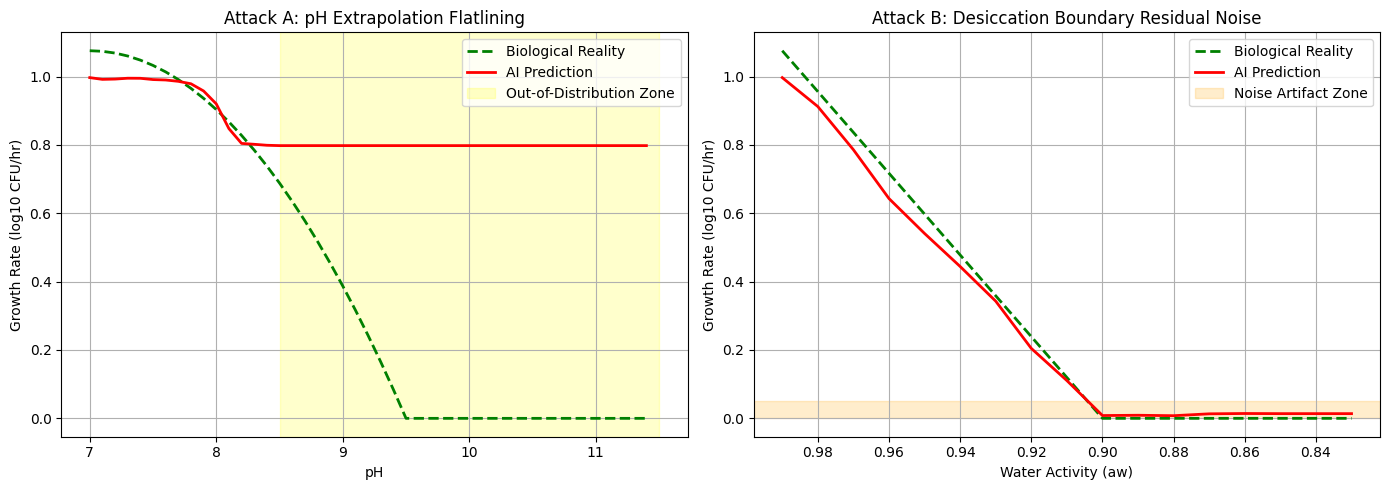

📈 Diagnostic plots saved as 'ai_safety_biological_audit.png'


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. DATA GENERATION & BIOLOGICAL GROUND TRUTH
# ==========================================
np.random.seed(42)
n_samples = 1200

temperature = np.random.uniform(4, 45, n_samples)
ph = np.random.uniform(4.0, 8.5, n_samples)
water_activity = np.random.uniform(0.85, 1.0, n_samples)

def calculate_true_growth(temp, p_h, aw):
    if temp < 5 or aw < 0.90 or p_h < 4.5:
        return 0.0
    # Cardinal parameter model simulation
    temp_factor = np.maximum(0, 1 - ((temp - 37) / (37 - 5))**2)
    ph_factor = np.maximum(0, 1 - ((p_h - 7.0) / (7.0 - 4.5))**2)
    aw_factor = np.maximum(0, (aw - 0.90) / (1.0 - 0.90))
    return 1.2 * temp_factor * ph_factor * aw_factor

true_growth = [calculate_true_growth(t, p, a) for t, p, a in zip(temperature, ph, water_activity)]
observed_growth = np.maximum(0, np.array(true_growth) + np.random.normal(0, 0.04, n_samples))

df = pd.DataFrame({
    'Temperature_C': temperature,
    'pH': ph,
    'Water_Activity': water_activity,
    'Growth_Rate': observed_growth
})

# ==========================================
# 2. MODEL TRAINING & INITIAL EVALUATION
# ==========================================
X = df[['Temperature_C', 'pH', 'Water_Activity']]
y = df['Growth_Rate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"📦 Model Trained. R2 Score: {r2_score(y_test, y_pred):.4f} | MSE: {mean_squared_error(y_test, y_pred):.4f}")

# ==========================================
# 3. ADVERSARIAL ATTACK & VISUALIZATION PIPELINE
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Attack A: pH Extrapolation Audit (35°C, Aw 0.99)
ph_range = np.arange(7.0, 11.5, 0.1)
ph_preds = []
ph_true = [calculate_true_growth(35.0, p, 0.99) for p in ph_range]

for p in ph_range:
    test_df = pd.DataFrame([{'Temperature_C': 35.0, 'pH': p, 'Water_Activity': 0.99}])
    ph_preds.append(model.predict(test_df)[0])

ax1.plot(ph_range, ph_true, 'g--', label='Biological Reality', linewidth=2)
ax1.plot(ph_range, ph_preds, 'r-', label='AI Prediction', linewidth=2)
ax1.axvspan(8.5, 11.5, color='yellow', alpha=0.2, label='Out-of-Distribution Zone')
ax1.set_title('Attack A: pH Extrapolation Flatlining')
ax1.set_xlabel('pH')
ax1.set_ylabel('Growth Rate (log10 CFU/hr)')
ax1.legend()
ax1.grid(True)

# Attack B: Desiccation Guardrail Audit (35°C, pH 7.0)
aw_range = np.arange(0.99, 0.83, -0.01)
aw_preds = []
aw_true = [calculate_true_growth(35.0, 7.0, a) for a in aw_range]

for a in aw_range:
    test_df = pd.DataFrame([{'Temperature_C': 35.0, 'pH': 7.0, 'Water_Activity': a}])
    aw_preds.append(model.predict(test_df)[0])

ax2.plot(aw_range, aw_true, 'g--', label='Biological Reality', linewidth=2)
ax2.plot(aw_range, aw_preds, 'r-', label='AI Prediction', linewidth=2)
ax2.axhspan(0.0, 0.05, color='orange', alpha=0.2, label='Noise Artifact Zone')
ax2.set_title('Attack B: Desiccation Boundary Residual Noise')
ax2.set_xlabel('Water Activity (aw)')
ax2.set_ylabel('Growth Rate (log10 CFU/hr)')
ax2.invert_xaxis() # Move from wet to dry
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('ai_safety_biological_audit.png', dpi=300)
plt.show()
print("📈 Diagnostic plots saved as 'ai_safety_biological_audit.png'")